In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pcj.utils import BASE_DIR, dados

In [3]:
# Dados para testes

dados_limpos, metadados, variaveis = dados(r"data\processed\dados_limpos.xlsx")

dados_limpos = dados_limpos.dropna().copy()

In [22]:
# Verificações

# print(dados_limpos['Data'].dtype, end='')
# print(dados_limpos['data_normalizada'].dtype)
# print(dados_limpos.columns)
# print(variaveis)
print(dados_limpos[variaveis])

       COR  TURB.   pH   ALC.    AC.  O.C.  O.D.    Cl   DUR.     Fe    Mn  \
0    200.0   64.0  7.0   29.0    3.0   6.3   2.0  16.0   36.0   3.23  0.09   
1    432.0  131.0  7.2   34.0    5.0   6.8   3.5  23.0   47.0   6.26  0.17   
2    690.0  241.0  7.4   38.0    8.0   7.5   4.8  33.0   66.0  11.20  0.32   
3    393.0   72.0  6.5   29.0    6.0   5.9   2.8  20.0   30.0   6.82  0.08   
4    868.0  238.0  7.1   31.0    7.0   7.2   4.1  21.0   33.0   9.55  0.12   
..     ...    ...  ...    ...    ...   ...   ...   ...    ...    ...   ...   
559   52.0   11.0  7.5   89.0    7.0  11.2   3.5  52.0   75.0   1.01  0.13   
560  180.0   48.0  7.9  100.0   11.0  46.2   5.8  60.0  124.0   1.40  0.36   
561   36.0    5.0  7.5   68.0    7.0   4.6   2.0  50.0   12.0   0.51  0.05   
562   65.0    9.0  7.7   87.0   31.0   9.1   4.5  57.0   61.0   0.60  0.07   
563  118.0   31.0  7.9  107.0  100.0  13.0   6.1  62.0  100.0   0.68  0.11   

     Cond.  Cianobacteria     C.F.  Clorofila     F  
0    131.

# KNN - Classificação

1) Seguindo o tutorial de https://medium.com/@ulissesmaffa/machine-learning-algoritmo-knn-26eb7b702c37

Diferenças entre o tutorial e o código nesse notebook:
- "x" substituído por "dados_limpos";
- "y" substituído por "colunas";
- Utilização de `KNeighborsRegressor` ao invés de `KNeighborsClassifier`, 
uma vez que não há dados categórigos na base de interesse;
- Utilização das métricas "RMSE", "MAE", e "r2" ao invés da matriz de confusão,
uma vez que matrizes de confusão funcionam para dados categóricos. As métricas citadas
funcionam com dados contínuos.

In [26]:
# Converte os títulos das colunas em uma Series do pandas
colunas = pd.Series(variaveis)

target_col = colunas[0] # Seleciona uma coluna (variável) alvo

In [29]:
# Normalizção dos dados

from sklearn.preprocessing import MinMaxScaler

normalize = MinMaxScaler(feature_range=(0,1))

limpos_norm = normalize.fit_transform(dados_limpos[variaveis])

limpos_norm = pd.DataFrame(limpos_norm, columns=colunas)

In [30]:
y = limpos_norm[target_col]

x = limpos_norm.drop(target_col, axis=1)    # Features = Todas as colunas, exceto a alvo

In [31]:
# Divisão em conjuntos de treinamento e teste para treinamento

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [33]:
# Inicialização do modelo

# from sklearn.neighbors import KNeighborsClassifier

from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=5)

# Treinamento

model.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [34]:
# Avaliação do Modelo com o método `score`

result = model.score(x_test, y_test)

print(f"Precisão do modelo no conjunto de teste: {result: .2%}")

Precisão do modelo no conjunto de teste:  72.62%


In [35]:
# Ajuste dos Hiperparâmetros com GridSearchCV

## Definição da grade de hiperparâmetros

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15], # Número de vizinhos considerados pelo algoritmo
    'weights': ['uniform', 'distance'], # Como o algoritmo deve pesar as distâncias dos vizinhos
                                        # 'uniform' = uniformemente, 'distance' = em função da distância entre vizinhos
    'metric': ['euclidean', 'manhattan', 'minkowski']   # Que métrica de distância usar
}

In [ ]:
# Executando o GridSearchCV

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(KNeighborsRegressor(), param_grid,
                            cv=5)   # Coloquei 5 por causa do tutorial, não sei do que se trata

grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [1, 3, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [38]:
# Resultados

print("Melhores parâmetros: ", grid_search.best_params_)

Melhores parâmetros:  {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}


In [39]:
# Treinamento com os Melhores Parâmetros

## Seleção dos melhores hiperparâmetros identificados pelo GridSearchCV

best_knn = KNeighborsRegressor(**grid_search.best_params_)

## Treinamento

best_knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [41]:
# Avaliação do modelo com Matriz de Confusão

# from sklearn.metrics import confusion_matrix,
# sns.heatmap(conf_matrix, annot=True, fmt='g')   # Estou seguindo o tutorial, não entendo isso direito
# plt.xlabel('Previsão')
# plt.ylabel('Real')
# plt.show()

# Avaliação do modelo com Métricas

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred = best_knn.predict(x_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


RMSE: 0.0565
MAE: 0.0290
R²: 0.6856


Automatizando o processo para verificar todas as variáveis

In [6]:
# Set up
# 1) Bibliotecas

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# 2) Seleção de variável e normalização de colunas

colunas = pd.Series(variaveis)

normalize = MinMaxScaler(feature_range=(0,1))

limpos_norm = normalize.fit_transform(dados_limpos[variaveis])

limpos_norm = pd.DataFrame(limpos_norm, columns=colunas)

# 3) Loop

# Selecionará cada variável como variável alvo
for target_col in colunas:
    print(f"Variável: {target_col}", "\n")

    y = limpos_norm[target_col]
    x = limpos_norm.drop(target_col, axis=1)    # Features = Todas as colunas, exceto a alvo
    
    # Divisão em conjuntos de treinamento e teste para treinamento
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

    # Inicialização do modelo
    model = KNeighborsRegressor(n_neighbors=5)

    # Treinamento
    model.fit(x_train, y_train)

    # Avaliação do Modelo com o método `score`
    result = model.score(x_test, y_test)
    print(f"Precisão do modelo no conjunto de teste: {result: .2%}")

    # Ajuste dos Hiperparâmetros com GridSearchCV
    ## Definição da grade de hiperparâmetros
    param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15], # Número de vizinhos considerados pelo algoritmo
    'weights': ['uniform', 'distance'], # Como o algoritmo deve pesar as distâncias dos vizinhos
                                        # 'uniform' = uniformemente, 'distance' = em função da distância entre vizinhos
    'metric': ['euclidean', 'manhattan', 'minkowski']   # Que métrica de distância usar
    }

    # Executando o GridSearchCV
    grid_search = GridSearchCV(KNeighborsRegressor(), param_grid,
                            cv=5)   # Coloquei 5 por causa do tutorial, não sei do que sse trata

    grid_search.fit(x_train, y_train)

    ## Resultados

    print("Melhores parâmetros: ", grid_search.best_params_)
    
    # Treinamento com os Melhores Parâmetros
    ## Seleção dos melhores hiperparâmetros identificados pelo GridSearchCV
    best_knn = KNeighborsRegressor(**grid_search.best_params_)

    ## Treinamento
    best_knn.fit(x_train, y_train)

    # Avaliação do modelo com Métricas
    y_pred = best_knn.predict(x_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print("--------------")


Variável: COR 

Precisão do modelo no conjunto de teste:  65.26%
Melhores parâmetros:  {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
RMSE: 0.0778
MAE: 0.0360
R²: 0.6410
--------------
Variável: TURB. 

Precisão do modelo no conjunto de teste:  78.91%
Melhores parâmetros:  {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
RMSE: 0.0538
MAE: 0.0281
R²: 0.8085
--------------
Variável: pH 

Precisão do modelo no conjunto de teste:  42.03%
Melhores parâmetros:  {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}
RMSE: 0.0582
MAE: 0.0447
R²: 0.5188
--------------
Variável: ALC. 

Precisão do modelo no conjunto de teste:  70.69%
Melhores parâmetros:  {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
RMSE: 0.0714
MAE: 0.0490
R²: 0.7873
--------------
Variável: AC. 

Precisão do modelo no conjunto de teste:  31.37%
Melhores parâmetros:  {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}
RMSE: 0.0607
MAE: 0.0355
R²: 0.3

# K-Means - Clustering

Os dados normalizados serão preparados selecionando variáveis relevantes (ex.: pH, condutividade elétrica, nitrato). 

O algoritmo será aplicado para agrupar os dados por similaridade, testando n_clusters de 2 a 10, definido pelo método do cotovelo (Kaufman; Russeeuw, 1990). 

O objetivo é identificar padrões espaciais ou temporais (ex.: regiões com alta turbidez) para manejo hídrico. 

In [ ]:
# Primeira tentativa

from sklearn.cluster import KMeans

# Salvar cópia das colunas das variáveis numa variável
X = dados_limpos[variaveis].copy()

# Eliminar células vaziass
Xnonan = X.dropna()

# kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(Xnonan)
print(X)

       COR  TURB.   pH  ALC.   AC.  O.C.  O.D.    Cl  DUR.     Fe    Mn  \
0    200.0   64.0  7.0  29.0   3.0   6.3   2.0  16.0  36.0   3.23  0.09   
1    432.0  131.0  7.2  34.0   5.0   6.8   3.5  23.0  47.0   6.26  0.17   
2    690.0  241.0  7.4  38.0   8.0   7.5   4.8  33.0  66.0  11.20  0.32   
3    393.0   72.0  6.5  29.0   6.0   5.9   2.8  20.0  30.0   6.82  0.08   
4    868.0  238.0  7.1  31.0   7.0   7.2   4.1  21.0  33.0   9.55  0.12   
..     ...    ...  ...   ...   ...   ...   ...   ...   ...    ...   ...   
571  217.0  134.0  7.5  48.0   9.0   9.7   4.2  39.0  63.0   1.57  0.11   
572  805.0  746.0  7.8  60.0  18.0  17.6   6.0  45.0  96.0   2.80  0.19   
573    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   
574    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   
575    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   

     Cond.  Cianobacteria     C.F.  Clorofila     F  
0    131.0         6600.0  23000.0       2.23

In [ ]:
# Setup

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Salvar cópia das colunas das variáveis numa variável
X = dados_limpos[variaveis].copy()

# Eliminar células vaziass
X_nonan = X.dropna(axis=0, how='any')
# Salvar o Index do DataFrame sem células vazias numa variável
idx_nonan = X_nonan.index

scaler = StandardScaler()   # Escalonamento = Normalização dos dados
X_scaled = scaler.fit_transform(X_nonan)

pca = PCA(n_components=0.95, random_state=0)
X_pca = pca.fit_transform(X_scaled)

In [6]:
# Teste

kmeans = KMeans(n_clusters=2, random_state=0)
cluster_labels = kmeans.fit_predict(X_nonan)
distancias = np.linalg.norm(X_nonan - kmeans.cluster_centers_[cluster_labels], axis=1)

kmeans.labels_

# distancias

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# Teste

kmeans = KMeans(n_clusters=2, random_state=0)
cluster_labels = kmeans.fit_predict(X_pca)
distancias = np.linalg.norm(X_pca - kmeans.cluster_centers_[cluster_labels], axis=1)

kmeans.labels_

# distancias

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,

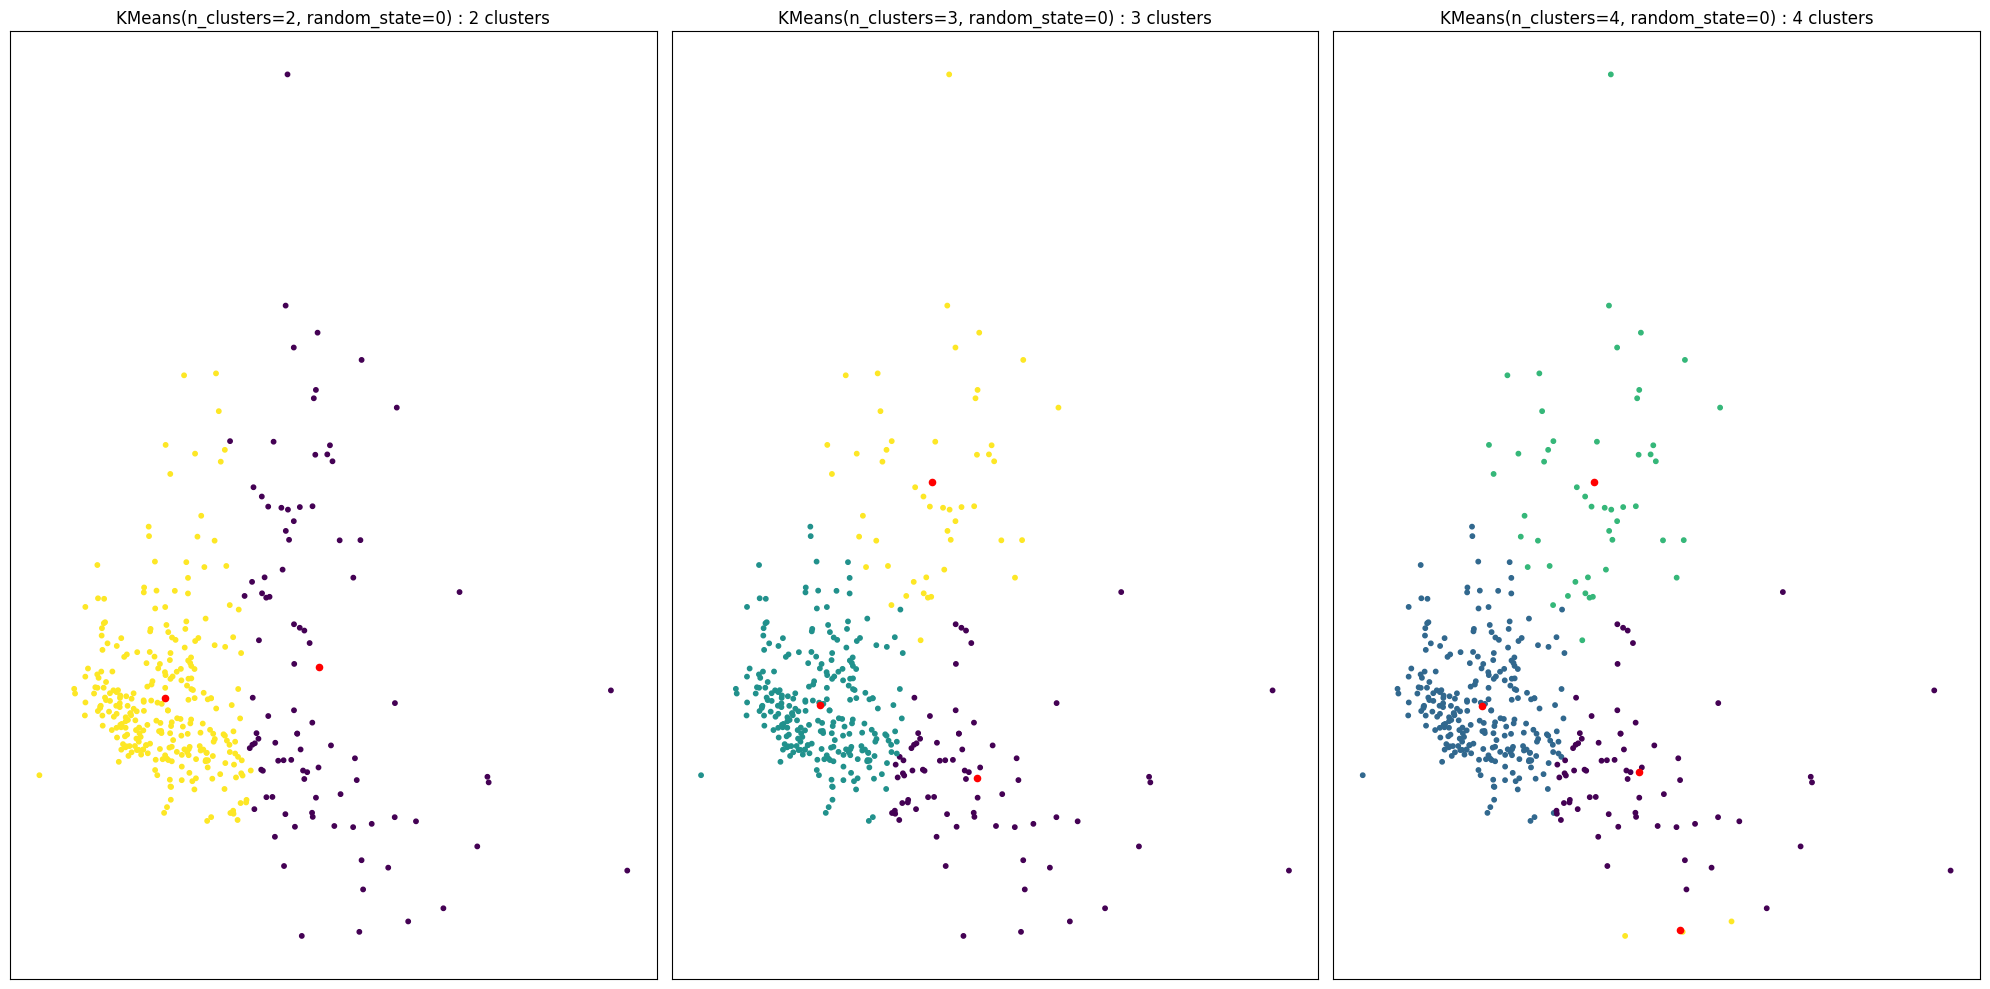

In [7]:
n_clusters_list = [2, 3, 4]

fig, axs = plt.subplots(
    1,
    len(n_clusters_list),
    figsize=(20, 10)
)

axs = axs.T

for i, n_clusters in enumerate(n_clusters_list):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
    kmeans.fit(X_pca)
    centers = kmeans.cluster_centers_

    axs[i].scatter(X_pca[:, 0], X_pca[:, 1], s=10, c=kmeans.labels_)
    axs[i].scatter(centers[:, 0], centers[:, 1], c="r", s=20)

    axs[i].set_title(f"{kmeans} : {n_clusters} clusters")

for ax in axs.flat:
    ax.label_outer()
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.show()

In [19]:
X_nonan

,COR,TURB.,pH,ALC.,AC.,O.C.,O.D.,Cl,DUR.,Fe,Mn,Cond.,Cianobacteria,C.F.,Clorofila,F
0,200.0,64.0,7.0,29.0,3.0,6.3,2.0,16.0,36.0,3.23,0.09,131.0,6600.0,23000.0,2.23,0.12
1,432.0,131.0,7.2,34.0,5.0,6.8,3.5,23.0,47.0,6.26,0.17,145.0,6850.0,23000.0,11.35,0.16
2,690.0,241.0,7.4,38.0,8.0,7.5,4.8,33.0,66.0,11.20,0.32,156.0,7100.0,23000.0,22.32,0.19
3,393.0,72.0,6.5,29.0,6.0,5.9,2.8,20.0,30.0,6.82,0.08,128.0,1100.0,30000.0,6.69,0.12
4,868.0,238.0,7.1,31.0,7.0,7.2,4.1,21.0,33.0,9.55,0.12,133.0,2100.0,30000.0,7.81,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,52.0,11.0,7.5,89.0,7.0,11.2,3.5,52.0,75.0,1.01,0.13,474.0,12701.0,4100.0,54.68,0.33
560,180.0,48.0,7.9,100.0,11.0,46.2,5.8,60.0,124.0,1.40,0.36,537.0,16770.0,4100.0,54.68,0.42
561,36.0,5.0,7.5,68.0,7.0,4.6,2.0,50.0,12.0,0.51,0.05,398.0,3466.0,2200.0,136.90,0.27
562,65.0,9.0,7.7,87.0,31.0,9.1,4.5,57.0,61.0,0.60,0.07,526.0,8866.0,2200.0,136.90,0.35


In [ ]:
# Teste

n_clusters = 3  # De acordo com os testes anteriores, 3 parece ser o melhor número de clusters

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
kmeans.fit(X_nonan)  # Talvez trocar X_nonan para X_pca
labels = kmeans.labels_

# Extrai datas que correspondem com as linhas de idx_nonan (algumas são removidas devido às células vazias)
dates = dados_limpos.loc[idx_nonan, 'data_normalizada']

# Subplots individuais para as variáveis
fig, axs = plt.subplots(len(variaveis), 1, figsize=(15, 4*len(variaveis)))

if len(variaveis) == 1:
    axs = [axs]

for i, var in enumerate(variaveis):
    scatter = axs[i].scatter(dates, X_nonan[var], c=labels, cmap='viridis', s=20)
    axs[i].set_ylabel(var)
    axs[i].set_xlabel('Data')
    axs[i].set_title(f'{var} ao longo do tempo (colorido segundo clustering K-Means)')
    axs[i].tick_params(axis='x', rotation=45)

cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
cbar = fig.colorbar(scatter, cax=cbar_ax, label='Cluster')
cbar.set_ticks(range(n_clusters))

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()

In [ ]:
n_clusters = 3  # De acordo com os testes anteriores, 3 parece ser o melhor número de clusters

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
kmeans.fit(X_pca)  # Alteração que eu tinha mencionado no último Jupyter Notebook
labels = kmeans.labels_

# Extrai datas que correspondem com as linhas de idx_nonan (algumas são removidas devido às células vazias)
dates = dados_limpos.loc[idx_nonan, 'data_normalizada']

# Subplots individuais para as variáveis
fig, axs = plt.subplots(len(variaveis), 1, figsize=(15, 4*len(variaveis)))

if len(variaveis) == 1:
    axs = [axs]

for i, var in enumerate(variaveis):
    scatter = axs[i].scatter(dates, X_nonan[var], c=labels, cmap='viridis', s=20)
    axs[i].set_ylabel(var)
    axs[i].set_xlabel('Data')
    axs[i].set_title(f'{var} ao longo do tempo (colorido segundo clustering K-Means)')
    axs[i].tick_params(axis='x', rotation=45)

cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
cbar = fig.colorbar(scatter, cax=cbar_ax, label='Cluster')
cbar.set_ticks(range(n_clusters))

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# Random Forest - Classificação

Os dados serão divididos em treinamento (80%) e teste (20%). 

O modelo será treinado com n_estimators=100 e profundidade limitada para evitar overfitting, classificando a qualidade da água (ex.: adequada/inadequada, conforme Resolução 
CONAMA 357/2005, Brasil, 2012).  

In [ ]:
from sklearn.ensemble import RandomForestClassifier # Documentação: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
from sklearn.datasets import make_classification    # Lendo a documentação (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html) 
                                                    # desse método, acho que ele só serve para gerar um problema aleatório de classificação.

# Estabelece as regras para o funcionamento do Classificador
clf = RandomForestClassifier(n_estimators=100,  # n_estimators=100 é default, mas como está nas instruções do relatório decidi evidenciar.
                             
                             bootstrap=True,    # bootstrap=True também é default, mas acho que é importante ele ser True para determinar a divisão de dados de treinamento e teste. Não sei ao certo.

                             max_samples=0.8,   # Pelo meu entendimento, isso deveria ser a quantidade de dados utilizados no treinamento, portanto, 80% do número de linhas (0.8 * shape[0]).
                                                                    # InvalidParameterError: The 'max_samples' parameter of RandomForestClassifier must be None, a float in the range (0.0, 1.0] or an int in the range [1, inf). Got 460.8 instead.
                                                                    # Acho que o certo então é só colocar 0.8 --> Funcionou

                            #  n_classes=2      # Acho que como nós queremos classificar a qualidade da água em "adequada" ou "inadequada", n_classes=2. 
                                                # Esquece: RandomForestClassifier.__init__() got an unexpected keyword argument 'n_classes'  
                                                                                     
                            #  n_features=      # Não entendo, mas parece importante
                             ) 

# Faz o fit do classificador, necessário para o funcionamento de estimators (NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.)

clf.fit(dados_limpos)   # Preciso de um argumento X e um y, mas não sei ao certo o que seria qual.

TypeError: BaseForest.fit() missing 1 required positional argument: 'y'

In [9]:
# clf.apply(dados_limpos)

clf.decision_path(dados_limpos)

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [7]:
dados_limpos.shape[0]*.8

460.8

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# Isolation Forest - Detecção de Anomalias

Após clustering, os dados serão processados para detectar anomalias isoladas, ajustando contamination (0,05–0,1) com base na análise exploratória. 

O algoritmo identificará picos de contaminação (ex.: fósforo elevado), focando em eventos críticos. 

In [15]:
from sklearn.ensemble import IsolationForest

X = dados_limpos[variaveis].copy()

isf = IsolationForest(contamination=0.05).fit(X)

isf.predict(X)

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1,
        1,  1, -1,  1, -1, -1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1